<a href="https://colab.research.google.com/github/yyy910805/notes/blob/master/visualization/introduction_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="white">.</font> | <font color="white">.</font> | <font color="white">.</font>
-- | -- | --
![NASA](http://www.nasa.gov/sites/all/themes/custom/nasatwo/images/nasa-logo.svg) | <h1><font size="+3">ASTG Python Courses</font></h1> | ![NASA](https://www.nccs.nasa.gov/sites/default/files/NCCS_Logo_0.png)

---

<CENTER>
<H1 style="color:red">
Introduction to Seaborn
</H1>
</CENTER>

# <font color="red">Reference Documents</font>

- <a href="seaborn.pydata.org">seaborn: statistical data visualization</a>
- <a href="https://www.datacamp.com/community/tutorials/seaborn-python-tutorial">Python Seaborn Tutorial For Beginners</a>
- <a href="https://www.c-sharpcorner.com/article/a-complete-python-seaborn-tutorial/">A Complete Python Seaborn Tutorial</a>
- <a href="https://www.journaldev.com/18583/python-seaborn-tutorial">Python Seaborn Tutorial </a>

# <font color="red"> What is Seaborn?</font>
- Python package for producing statistical graphics.
- It comes equipped with preset styles and color palettes so you can create complex, aesthetically pleasing charts with a few lines of code.
- It makes visualization a central part of exploring and understanding data.
- Its dataset-oriented plotting functions operate on Pandas DataFrames and Numpy arrays containing whole datasets and internally perform the necessary semantic mapping and statistical aggregation to produce informative plots.
- It is built on top of Matplotlib, but it's meant to serve as a complement, not a replacement.. Behind the scenes, Seaborn uses matplotlib to draw plots.
- **Seaborn is an important tool used in Exploratory Data Analysis.**

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Seaborn Settings

- Matplotlib is highly customizable, but it can be complicated at the same time as it is hard to know what settings to tweak to achieve a good looking plot.
- Seaborn comes with a number of themes and a high-level interface for controlling the look of matplotlib figures.

The default default `seaborn` theme, scaling, and color palette is done through the setting:

```python
   sns.set()
```

It relies on the Matplotlib rcParams customization.

**Consider the following Matplotlib example**

In [2]:
def plot_cosine_sine():

    X = np.linspace(-np.pi, np.pi, 256,endpoint=True)
    C = np.cos(X)
    S = np.sin(X)

    # Plot cosine using blue color with a continuous line of width 1 (pixels)
    plt.plot(X, C, color="blue", linewidth=1.0, linestyle="-", label="cos");

    # Plot sine using green color with a continuous line of width 1 (pixels)
    plt.plot(X, S, color="green", linewidth=1.0, linestyle="-", label="sin");

    plt.legend(loc='best')

    # Set x limits
    plt.xlim(-4.0,4.0);

    # Set x ticks
    plt.xticks(np.linspace(-4,4,5,endpoint=True));

    # Set y limits
    plt.ylim(-1.05,1.05);

    # Set y ticks
    plt.yticks(np.linspace(-1,1,5,endpoint=True));

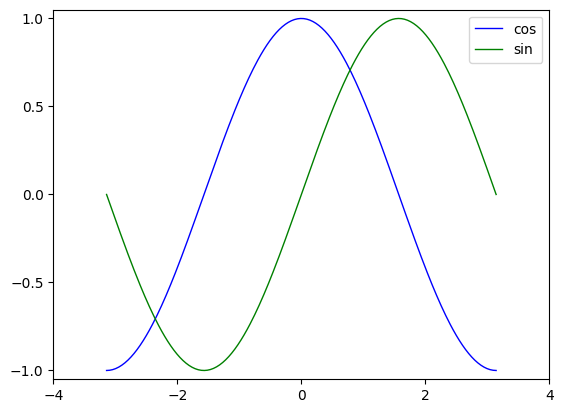

In [3]:
plot_cosine_sine()

**Let us run the same example with Seaborn settings**

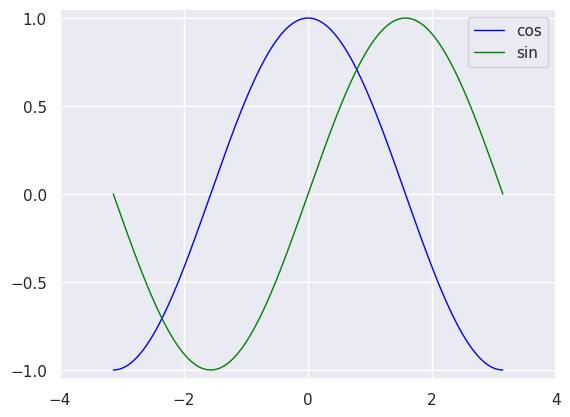

In [4]:
sns.set()
plot_cosine_sine()

We can also set the background through the function `set_style`. Some possible settings are:

```python
sns.set_style("dark")
sns.set_style("whitegrid")
sns.set_style("white")
```

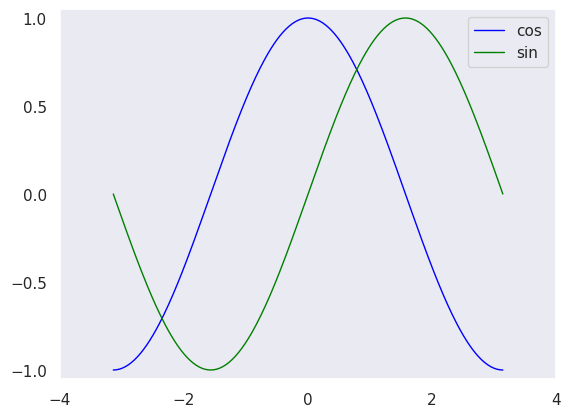

In [5]:
sns.set_style("dark")
plot_cosine_sine()

You can use the function `despine` to remove the spines.

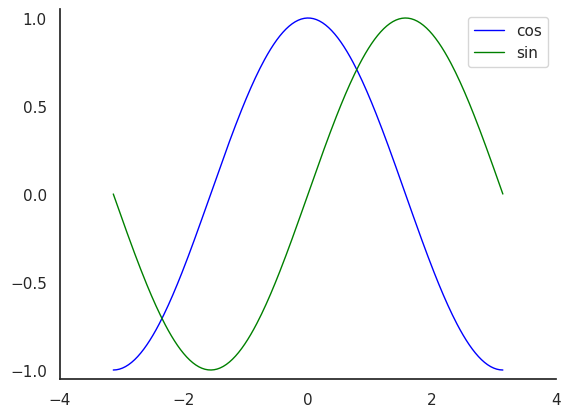

In [6]:
sns.set_style("white")
plot_cosine_sine()
sns.despine()

Using subplot and temporarily setting figure style:

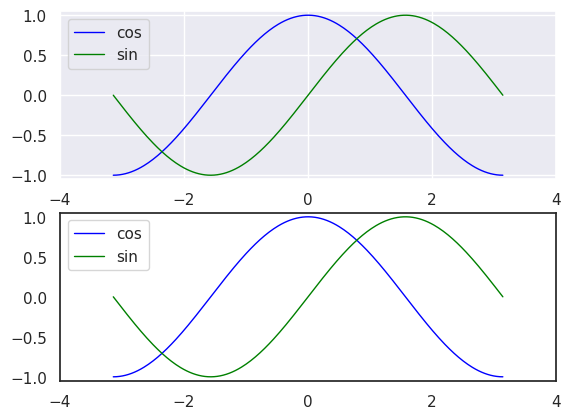

In [7]:
with sns.axes_style("darkgrid"):
   plt.subplot(211)
   plot_cosine_sine()
plt.subplot(212)
plot_cosine_sine()

# <font color="red">Identifying Statistical Relationships</font>

- Statistical analysis is a process of understanding how variables in a dataset relate to each other and how those relationships depend on other variables.
- When data are visualized properly, the human visual system can see trends and patterns that indicate a relationship.

In [8]:
mpg = sns.load_dataset("mpg")
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


## `scatterplot`

- The relationship between `x` and `y` can be shown for different subsets of the data using the `hue`, `size`, and `style` parameters.
- These parameters control what visual semantics are used to identify the different subsets.

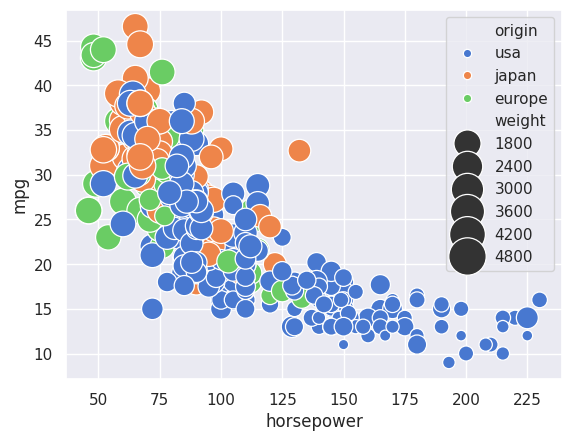

In [9]:
sns.set()

sns.scatterplot(x="horsepower", y="mpg",
                hue="origin", size="weight",
                sizes=(400, 40), palette="muted",
                data=mpg);

## `lineplot`

<Axes: xlabel='horsepower', ylabel='mpg'>

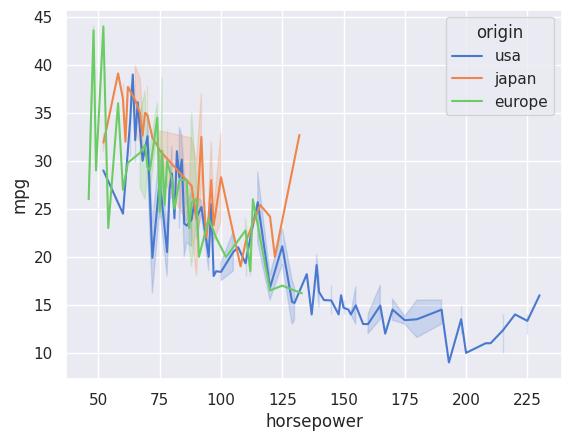

In [10]:
sns.lineplot(x="horsepower", y="mpg",
            hue="origin", palette="muted",
            data=mpg)

### `relplot`

- Designed to visualize many different statistical relationships.

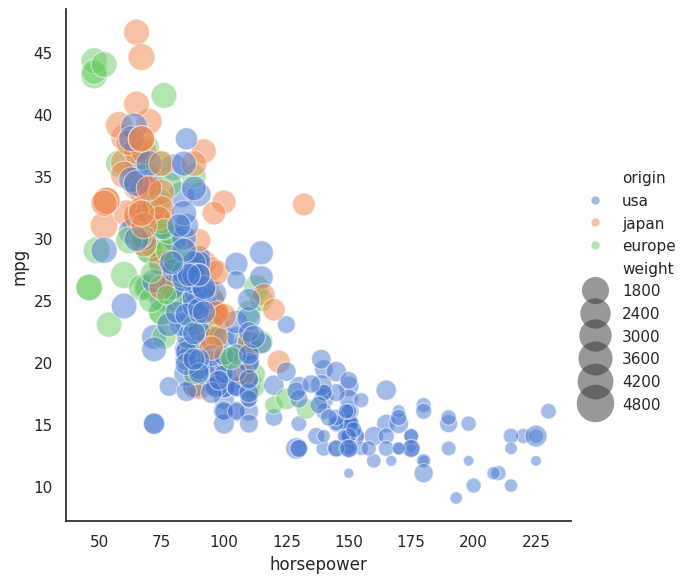

In [11]:
sns.set(style="white")

# Plot miles per gallon against horsepower with other semantics
sns.relplot(x="horsepower", y="mpg",
            hue="origin", size="weight",
            sizes=(400, 40), alpha=.5, palette="muted",
            height=6, data=mpg)

# <font color="red">Manipulating Categorical Data</font>



## Categorical scatterplots

In [12]:
iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### `stripplot`

- Draw a scatterplot where one variable is categorical.

/tmp/ipython-input-1981978816.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x="measurement", y="value", hue="species",
/tmp/ipython-input-1981978816.py:14: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x="measurement", y="value", hue="species",
/tmp/ipython-input-1981978816.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="measurement", y="value", hue="species",


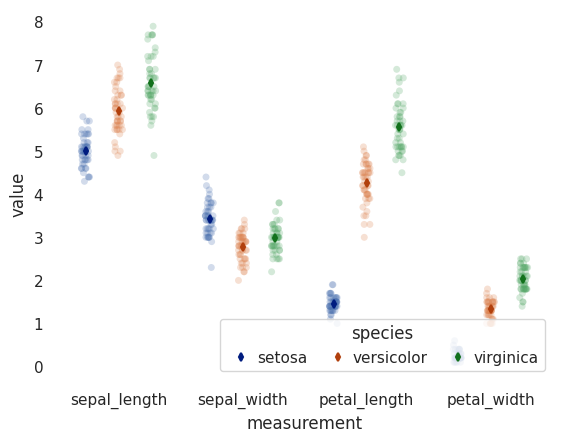

In [13]:
# "Melt" the dataset to "long-form" or "tidy" representation
iris_m = pd.melt(iris, "species", var_name="measurement")

# Initialize the figure
f, ax = plt.subplots()
sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.stripplot(x="measurement", y="value", hue="species",
              data=iris_m, dodge=True, jitter=True,
              alpha=.25, zorder=1)

# Show the conditional means
sns.pointplot(x="measurement", y="value", hue="species",
              data=iris_m, dodge=.532, join=False, palette="dark",
              markers="d", scale=.75, ci=None)

# Improve the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[3:], labels[3:], title="species",
          handletextpad=0, columnspacing=1,
          loc="lower right", ncol=3, frameon=True)

### `swarmplot`

- Draw a categorical scatterplot with non-overlapping points.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 27.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 24.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 39.3% of the points cannot be place

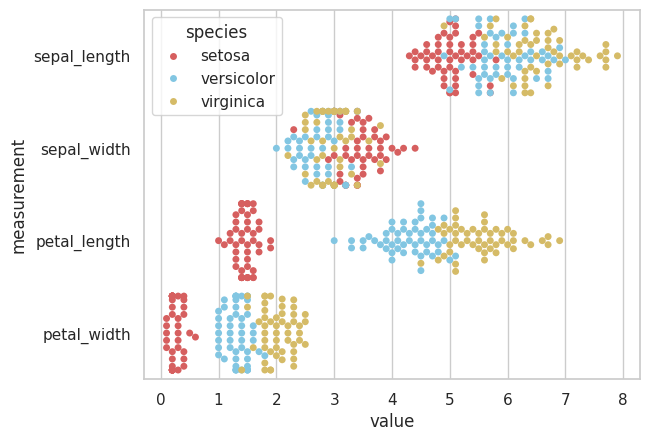

In [14]:
sns.set(style="whitegrid", palette="muted")

# "Melt" the dataset to "long-form" or "tidy" representation
iris_m = pd.melt(iris, "species", var_name="measurement")

# Draw a categorical scatterplot to show each observation
sns.swarmplot(x="value", y="measurement", hue="species",
              palette=["r", "c", "y"], data=iris_m);

## Categorical Distribution Plots

In [15]:
planets = sns.load_dataset("planets")
planets

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


### `boxplot`
- Draw a box plot to show distributions with respect to categories.
- A box plot shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable.
- The box shows the quartiles of the dataset.

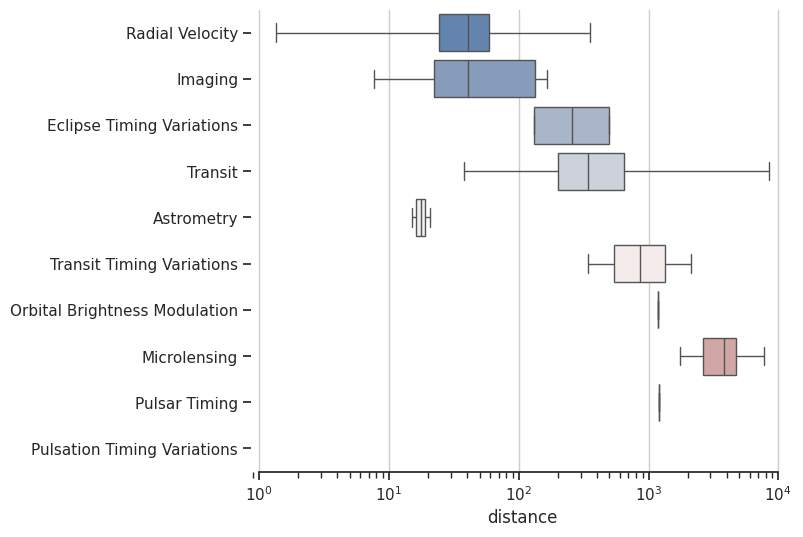

In [17]:
sns.set(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
ax.set_xscale("log")

# Plot the orbital period with horizontal boxes
sns.boxplot(x="distance", y="method", data=planets,
            whis=[0,100], hue="method",palette="vlag")

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True, left=True)

### `violinplot`
- Draw a combination of boxplot and kernel density estimate.
- It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared.
- This can be an effective and attractive way to show multiple distributions of data at once.

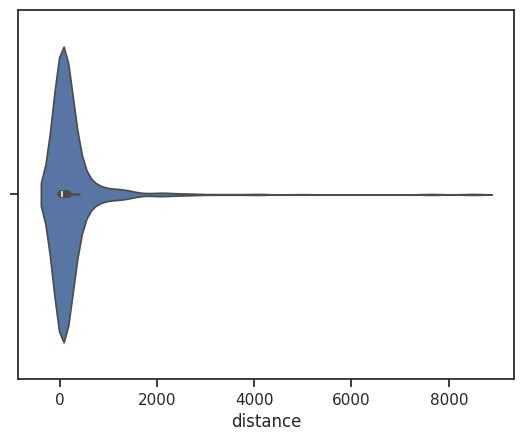

In [18]:
ax = sns.violinplot(x=planets["distance"])

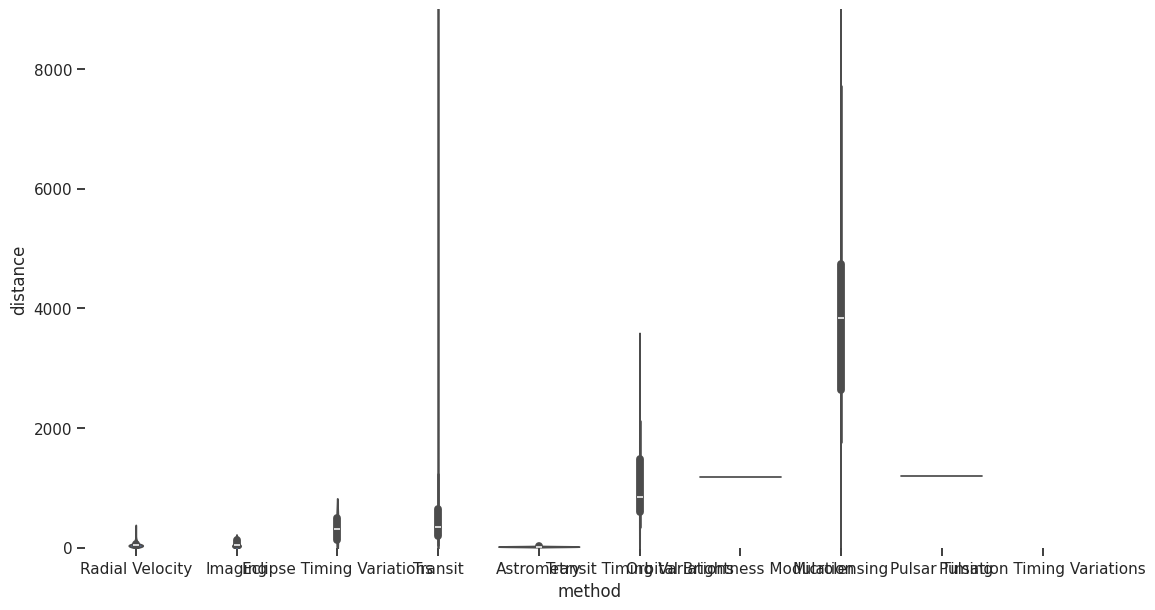

In [19]:
f, ax = plt.subplots(figsize=(13, 7))

sns.violinplot(x="method", y="distance", data=planets)
# Finalize the figure
ax.set(ylim=(-10, 9000))
sns.despine(left=True, bottom=True)

In [20]:
df = sns.load_dataset("brain_networks", header=[0, 1, 2], index_col=0)
df

network           1                     2                     3             \
node              1                     1                     1              
hemi             lh         rh         lh         rh         lh         rh   
0         56.055744  92.031036   3.391576  38.659683  26.203819 -49.715569   
1         55.547253  43.690075 -65.495987 -13.974523 -28.274963 -39.050129   
2         60.997768  63.438793 -51.108582 -13.561346 -18.842947  -1.214659   
3         18.514868  12.657158 -34.576603 -32.665958  -7.420454  17.119448   
4         -2.527392 -63.104668 -13.814151 -15.837989 -45.216927   3.483550   
..              ...        ...        ...        ...        ...        ...   
915       -7.429513  -4.813219  -3.670537   1.442261 -19.680431 -29.109356   
916      -33.554138 -38.605621 -25.664803 -30.252352   5.562785  20.182186   
917      -78.539566 -74.197189 -54.041595 -39.970291 -14.277059 -30.606461   
918     -103.235825 -98.744286 -40.109543 -44.907734  12.109148   1.621340   
919      -36.288868 -10.762070 -30.356262 -23.319504  14.252188 -27.559860   

network          4                     5             ...          16  \
node             1                     1             ...           3   
hemi            lh         rh         lh         rh  ...          rh   
0        47.461037  26.746613 -35.898861  -1.889181  ...    0.607904   
1        -1.210660 -19.012897  19.568010  15.902983  ...   57.495071   
2       -65.575806 -85.777428  19.247454  37.209419  ...   28.317369   
3       -41.800869 -58.610184  32.896915  11.199619  ...   71.439629   
4       -62.613335 -49.076508  18.396759   3.219077  ...   95.597565   
..             ...        ...        ...        ...  ...         ...   
915      -3.376562  -8.764893   0.017912 -25.305094  ...   58.285793   
916      17.911247  24.653582 -32.935612 -21.783203  ...   59.864819   
917      60.628521  62.027023 -32.800556 -37.021500  ...   68.767868   
918      33.765560  55.356071 -14.330512 -17.224781  ...  103.155251   
919      17.279512 -19.060152  26.558777  21.377319  ...  102.086304   

network                                 17                                   \
node              4                      1                     2              
hemi             lh          rh         lh         rh         lh         rh   
0        -70.270546   77.365776 -21.734550   1.028253   7.791784  68.903725   
1        -76.393219  127.261360 -13.035799  46.381824 -15.752450  31.000332   
2          9.063977   45.493263  26.033442  34.212200   1.326110 -22.580757   
3         65.842979  -10.697547  55.297466   4.255006  -2.420144  12.098393   
4         50.960453  -23.197300  43.067562  52.219875  28.232882 -11.719750   
..              ...         ...        ...        ...        ...        ...   
915       68.557411   22.833048  76.179489  51.934669  -6.614513  -6.690762   
916       23.004578    7.657463  50.962399  13.696922  63.503616  57.401176   
917       49.664017   64.551498  43.800747   8.144480  47.281460  70.499649   
918      106.454849    9.046827  46.674419  40.954796   0.877180  37.577152   
919       80.051140   -2.642610 -12.229620  -6.596726  17.665163  16.153173   

network                                    
node             3                      4  
hemi            lh          rh         lh  
0       -10.520872  120.490463 -39.686432  
1       -39.607521   24.764011 -36.771008  
2        12.985169  -75.027451   6.434262  
3       -15.819172  -37.361431  -4.650954  
4         5.453649    5.169828  87.809135  
..             ...         ...        ...  
915      22.893030   48.274380  76.228455  
916      24.974548   51.972153  64.538788  
917      66.994400   81.539246  64.969772  
918      20.517746    3.124434  56.718388  
919       8.300399   33.687531  17.960655  

[920 rows x 62 columns]

/tmp/ipython-input-3983695888.py:22: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=1`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(data=corr_df, palette="Set3", bw=1, cut=.2, linewidth=1)


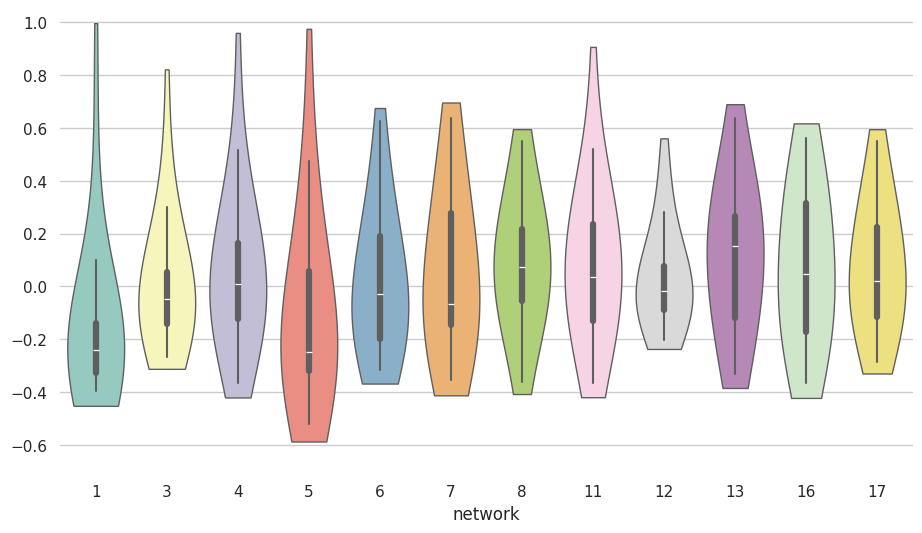

In [21]:
sns.set(style="whitegrid")

# Load the example dataset of brain network correlations
df = sns.load_dataset("brain_networks", header=[0, 1, 2], index_col=0)

# Pull out a specific subset of networks
used_networks = [1, 3, 4, 5, 6, 7, 8, 11, 12, 13, 16, 17]
used_columns = (df.columns.get_level_values("network")
                          .astype(float)
                          .isin(used_networks))
df = df.loc[:, used_columns]

# Compute the correlation matrix and average over networks
corr_df = df.corr().groupby(level="network").mean()
corr_df.index = corr_df.index.astype(int)
corr_df = corr_df.sort_index().T

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 6))

# Draw a violinplot with a narrower bandwidth than the default
sns.violinplot(data=corr_df, palette="Set3", bw=1, cut=.2, linewidth=1)

# Finalize the figure
ax.set(ylim=(-.7, 1.05))
sns.despine(left=True, bottom=True)

### `boxenplot`
- Draw an enhanced box plot for larger datasets.
- This style of plot was originally named a “letter value” plot because it shows a large number of quantiles that are defined as “letter values”.
- It is similar to a box plot in plotting a nonparametric representation of a distribution in which all features correspond to actual observations.
- By plotting more quantiles, it provides more information about the shape of the distribution, particularly in the tails.

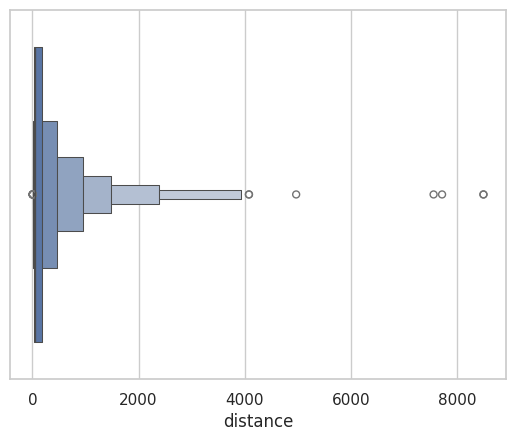

In [22]:
ax = sns.boxenplot(x=planets["distance"])

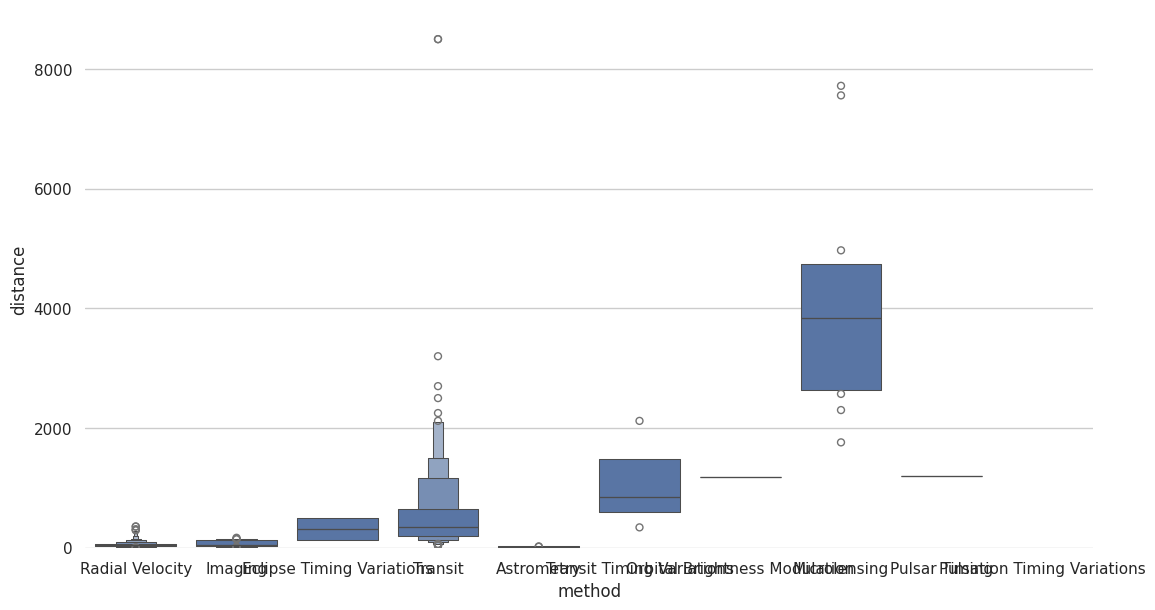

In [23]:
f, ax = plt.subplots(figsize=(13, 7))

sns.boxenplot(x="method", y="distance", data=planets)
# Finalize the figure
ax.set(ylim=(-10, 9000))
sns.despine(left=True, bottom=True)

## Categorical Estimate Plots

In [24]:
titanic = sns.load_dataset("titanic")
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### `pointplot`
- Show point estimates and confidence intervals using scatter plot glyphs.
- A point plot represents an estimate of central tendency for a numeric variable by the position of scatter plot points and provides some indication of the uncertainty around that estimate using error bars.
- Point plots can be more useful than bar plots for focusing comparisons between different levels of one or more categorical variables.

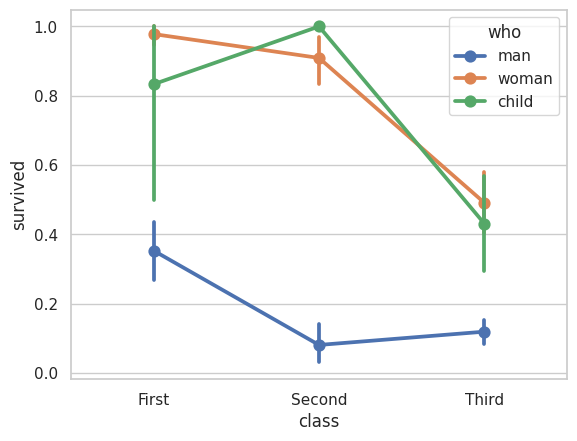

In [25]:
ax = sns.pointplot(x="class", y="survived", hue="who",
                   data=titanic)

### `countplot`
- Show the counts of observations in each categorical bin using bars.
- A count plot can be thought of as a histogram across a categorical, instead of quantitative, variable.

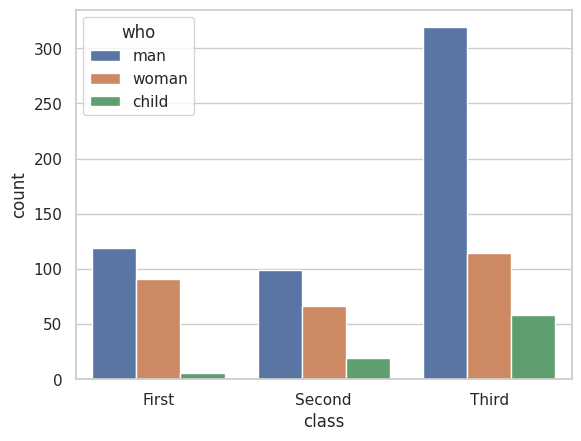

In [26]:
ax = sns.countplot(x="class", hue="who", data=titanic)

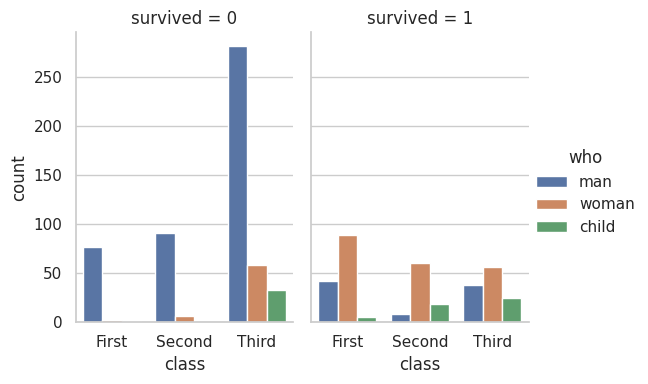

In [27]:
g = sns.catplot(x="class", hue="who", col="survived",
                data=titanic, kind="count",
                height=4, aspect=.7);

### `barplot`
- Show point estimates and confidence intervals as rectangular bars.
- A bar plot represents an estimate of central tendency for a numeric variable with the height of each rectangle and provides some indication of the uncertainty around that estimate using error bars.

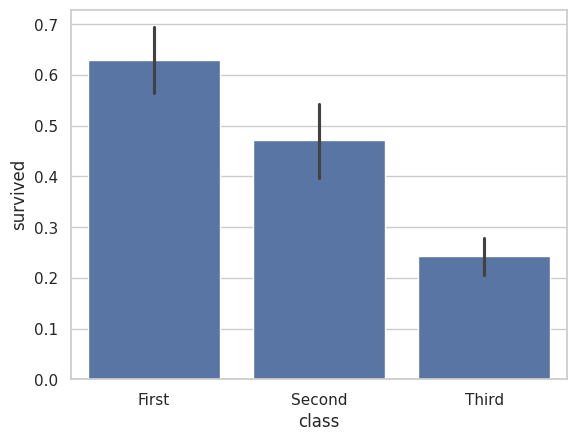

In [28]:
ax = sns.barplot(x="class", y="survived", data=titanic)

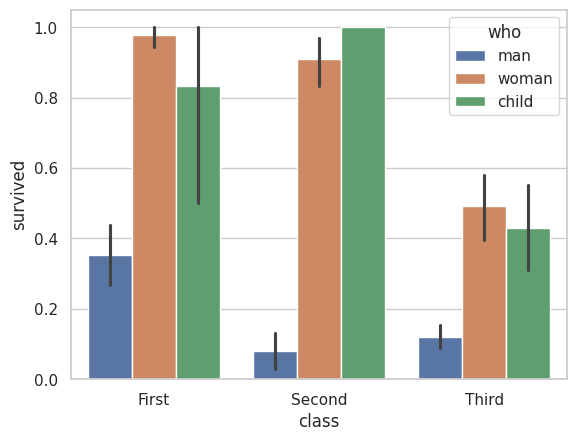

In [29]:
ax = sns.barplot(x="class", y="survived", hue="who", data=titanic)

# <font color="red">Visualizing the Distribution of a Dataset</font>



### `displot`

- Flexibly plot a univariate distribution of observations.

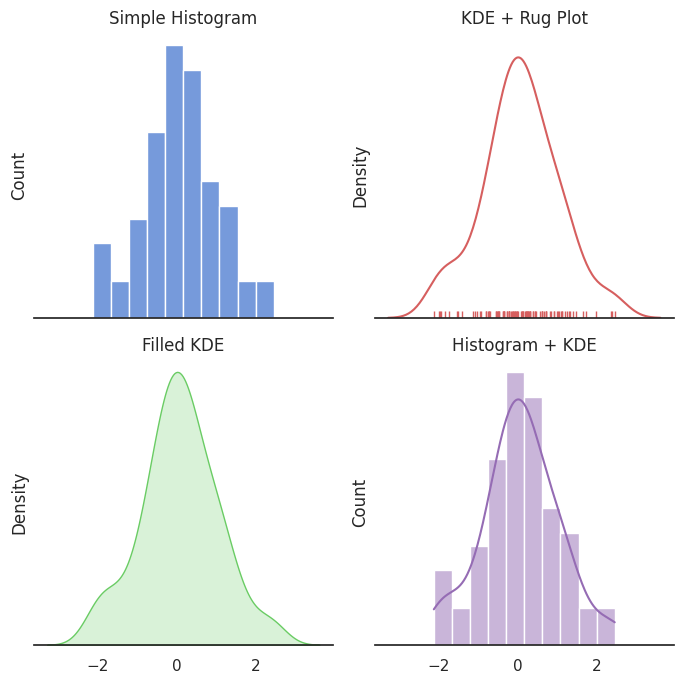

In [38]:
sns.set(style="white", palette="muted", color_codes=True)
rs = np.random.RandomState(10)

# Set up the matplotlib figure
f, axes = plt.subplots(2, 2, figsize=(7, 7), sharex=True)
sns.despine(left=True)

# Generate a random univariate dataset
d = rs.normal(size=100)

# Plot a simple histogram with binsize determined automatically
sns.histplot(d, kde=False, color="b", ax=axes[0, 0])
axes[0, 0].set_title("Simple Histogram")

# Plot a kernel density estimate and rug plot
sns.kdeplot(d, color="r", ax=axes[0, 1])
sns.rugplot(d, color="r", ax=axes[0, 1])
axes[0, 1].set_title("KDE + Rug Plot")

# Plot a filled kernel density estimate
sns.kdeplot(d, fill=True, color="g", ax=axes[1, 0])
axes[1, 0].set_title("Filled KDE")

# Plot a histogram and kernel density estimate
sns.histplot(d, kde=True, color="m", ax=axes[1, 1])
axes[1, 1].set_title("Histogram + KDE")

plt.setp(axes, yticks=[])
plt.tight_layout()

### `kdeplot`

- Fit and plot a univariate or bivariate kernel density estimate.

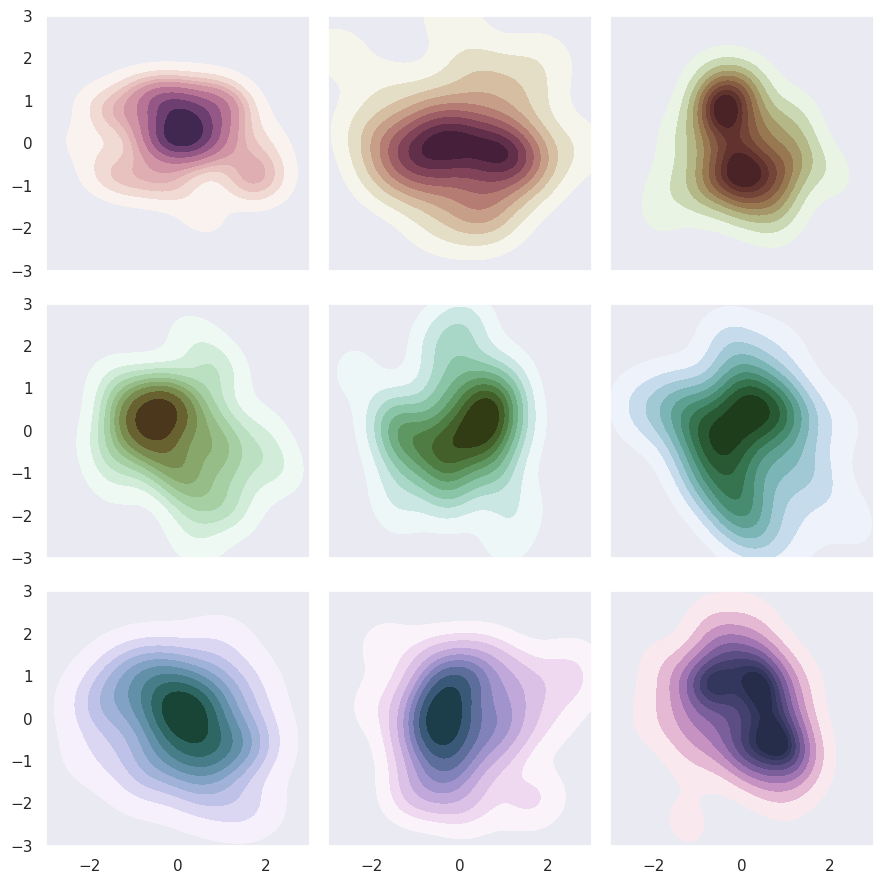

In [40]:
sns.set(style="dark")
rs = np.random.RandomState(500)

# Set up the matplotlib figure
f, axes = plt.subplots(3, 3, figsize=(9, 9), sharex=True, sharey=True)

# Rotate the starting point around the cubehelix hue circle
for ax, s in zip(axes.flat, np.linspace(0, 3, 10)):

    # Create a cubehelix colormap to use with kdeplot
    cmap = sns.cubehelix_palette(start=s, light=1, as_cmap=True)

    # Generate and plot a random bivariate dataset
    x, y = rs.randn(2, 50)
    sns.kdeplot(x=x, y=y, cmap=cmap, fill=True, cut=5, ax=ax)
    ax.set(xlim=(-3, 3), ylim=(-3, 3))

f.tight_layout()

###  `pairplot`

- Plot pairwise relationships in a dataset.

In [ ]:
sns.set(style="ticks")
#iris = sns.load_dataset("iris")
sns.pairplot(iris, hue="species");

# <font color="red">Visualizing Linear Relationships</font>


### `regplot`

- Plot data and a linear regression model fit.

In [ ]:
g = sns.regplot(x="sepal_length", y="sepal_width",
                 data=iris)

### `lmplot`

- Enhance a scatterplot to include a linear regression model (and its uncertainty).

In [ ]:
iris = sns.load_dataset("iris")

# Plot sepal with as a function of sepal_length across days
g = sns.lmplot(x="sepal_length", y="sepal_width", hue="species",
               truncate=True, height=5, data=iris)

# Use more informative axis labels than are provided by default
g.set_axis_labels("Sepal length (mm)", "Sepal width (mm)");

###  `jointplot`
- Draw a plot of two variables with bivariate and univariate graphs.

In [ ]:
g = sns.jointplot(x="sepal_length", y="sepal_width", data=iris)

In [ ]:
g = sns.jointplot(x="sepal_length", y="sepal_width", data=iris,
                  kind="reg", space=0, color="g")

# Useful Functions

### `heatmap`

- Plot rectangular data as a color-encoded matrix.

In [ ]:
uniform_data = np.random.rand(10, 12)
ax = sns.heatmap(uniform_data)

In [ ]:
sns.set()

# Load the example flights dataset and conver to long-form
flights_long = sns.load_dataset("flights")
flights = flights_long.pivot("month", "year", "passengers")

# Draw a heatmap with the numeric values in each cell
f, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(flights, annot=True, fmt="d", linewidths=.5, ax=ax);

### `clustermap`
- Plot a matrix dataset as a hierarchically-clustered heatmap.

In [ ]:
species = iris.pop("species")
g = sns.clustermap(iris)